In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.interpolate import interp1d
from wrf_io import postproc

from MITRotor import BEM, IEA10MW, BEMGeometry, NoTipLoss, KraghAerodynamics, Madsen_Annulus_Shapiro, NoTangentialInduction

In [2]:
fontsize = 24
plt.rcParams['xtick.labelsize'] = 20 
plt.rcParams['ytick.labelsize'] = 20 

plt.rcParams.update({
    'text.usetex': True,
    'text.latex.preamble': r'\usepackage{amsfonts}'
})

In [3]:
casenames = [r's0_v4', r'sn2_v2', r's0_v2',r's2_v2', r'sn4_v0', r'sn2_v0', r's0_v0', r's2_v0', r's4_v0', r'sn2_vn2', r's0_vn2', r's2_vn2', r's0_vn4']
# casenames = [r's0_v0']

# casenames = [r's000_vn400',
#              r's000_vn375',
#              r's000_vn350',
#              r's000_vn325',
#              r's000_vn300',
#              r's000_vn275',
#              r's000_vn250',
#              r's000_vn225',
#              r's000_vn200',
#              r's000_vn175',
#              r's000_vn150',
#              r's000_vn125',
#              r's000_vn100',
#              r's000_vn075',
#              r's000_vn050',
#              r's000_vn025',
#              r's000_v000',
#              r's000_v025',
#              r's000_v050',
#              r's000_v075',
#              r's000_v100',
#              r's000_v125',
#              r's000_v150',
#              r's000_v175',
#              r's000_v200',
#              r's000_v225',
#              r's000_v250',
#              r's000_v275',
#              r's000_v300',
#              r's000_v325',
#              r's000_v350',
#              r's000_v375',
#              r's000_v400'
#              ]

file_list = []
for count in range(len(casenames)):
    # file_list.append('/scratch/09909/smata/wrf_les_sweep/runs/just_for_profiles/gad_sweep/'+casenames[count]+'/input_sounding')
    file_list.append('/scratch/09909/smata/wrf_les_sweep/runs/10MW/rate/gad_sweep/'+casenames[count]+'/input_sounding')


data = postproc.extract_sounding(file_list)

In [4]:
nElements = 26
nSections = 158

In [5]:
rotor = IEA10MW()

bem = BEM(rotor=rotor, geometry=BEMGeometry(Nr=nElements, Ntheta=nSections), aerodynamic_model=KraghAerodynamics(), tiploss_model=NoTipLoss(), momentum_model=Madsen_Annulus_Shapiro(), tangential_induction_model=NoTangentialInduction())

pitch, tsr, yaw = np.deg2rad(0), 10.634, np.deg2rad(0.0)
sol = bem(pitch, tsr, yaw)

In [6]:
z = sol.geom.mu_mesh * rotor.R * np.cos(sol.geom.theta_mesh) + 378

In [7]:
xs = [0,1,1,1,2,2,2,2,2,3,3,3,4]
ys = [2,1,2,3,0,1,2,3,4,1,2,3,2]

shear = [0,-2,0,2,-4,-2,0,2,4,-2,0,2,0]
veer  = [4,2,2,2,0,0,0,0,0,-2,-2,-2,-4]

cp        = np.zeros_like(xs, dtype='float')
power     = np.zeros_like(xs, dtype='float')
thrust    = np.zeros_like(xs, dtype='float')
induction = np.zeros_like(xs, dtype='float')

fig, ax = plt.subplots(nrows=5, ncols=5, figsize=(20, 15), constrained_layout=True,sharex=True, sharey=True)

for count in range(len(casenames)):
    u_func = interp1d(data[casenames[count]][:,0],data[casenames[count]][:,1])
    v_func = interp1d(data[casenames[count]][:,0],data[casenames[count]][:,2])

    u = u_func(z)
    v = v_func(z)

    wdir = np.arctan2(v,u)

    U = (u**2 + v**2)**(1/2)

    bem = BEM(rotor=rotor, geometry=BEMGeometry(Nr=nElements, Ntheta=nSections), aerodynamic_model=KraghAerodynamics(), tiploss_model=NoTipLoss(), momentum_model=Madsen_Annulus_Shapiro(veer=veer[count]), tangential_induction_model=NoTangentialInduction())

    sol = bem(pitch, tsr, yaw, v_inf=7.0, U = U/7, wdir = wdir)

    cp[count] = sol.Cp()
    power[count] = sol.power()
    thrust[count] = sol.thrust()
    induction[count] = sol.a()

    a_mom = np.linspace(0,0.75,50)
    ct_mom = 4 * a_mom * (1 - a_mom)
    ax[xs[count],ys[count]].plot(a_mom, ct_mom, '#ff3c00',linewidth=3,zorder=1)

    ct_mad = np.linspace(0,1.5,75)
    k1 = 0.2460
    k2 = 0.0586
    k3 = 0.0883
    a_mad = k3 * ct_mad**3 + k2 * ct_mad**2 + k1 * ct_mad
    ax[xs[count],ys[count]].plot(a_mad, ct_mad, 'k--',linewidth=3,zorder=2)

    mesh = ax[xs[count],ys[count]].scatter(sol.a(), sol.Ct(), cmap='viridis', s=110, edgecolor='none',color='#176d2e',zorder=3)

    # ax[xs[count],ys[count]].set_aspect('equal')
    ax[xs[count],ys[count]].set_xlim([0,0.6])
    ax[xs[count],ys[count]].set_ylim([0,1.35])

    ax[4,4].scatter(sol.a(), sol.Ct(), cmap='viridis', s=110, edgecolor='none',color='#176d2e',zorder=3,alpha=0.25)

ax[0,0].axis('off')
ax[0,1].axis('off')
ax[0,3].axis('off')
ax[0,4].axis('off')

ax[1,0].axis('off')
ax[1,4].axis('off')

ax[3,0].axis('off')
ax[3,4].axis('off')

ax[4,0].axis('off')
ax[4,1].axis('off')
ax[4,3].axis('off')
# ax[4,4].axis('off')
for spine in ax[4,4].spines.values():
    spine.set_linewidth(2.5)
    spine.set_edgecolor('red')

ax[4,4].plot(a_mom, ct_mom, '#ff3c00',linewidth=3,zorder=1)
ax[4,4].plot(a_mad, ct_mad, 'k--',linewidth=3,zorder=2)
ax[4,4].set_title('Full Ensemble', fontweight='bold',color='r')

ax[2,0].set_ylabel('$C_T$ [-]', fontsize=20)
ax[4,2].set_xlabel('$a$ [-]', fontsize=20)
# Add a single colorbar on the right-hand side
# cbar = fig.colorbar(mesh, ax=ax, location='right', shrink=1)
# cbar.set_label('Deviation in axial force from uniform [\%]',fontsize=25)


# Add the number line below the subplots
line_y = -0.04  # Y-position for the line (below the subplots)
line_x_start, line_x_end = -0.03, 1  # Start and end positions of the line (normalized coordinates)

# Draw the line
fig.lines.extend([
    plt.Line2D([line_x_start, line_x_end], [line_y, line_y], color="black", transform=fig.transFigure, linewidth=2)
])

# Add text to the number line
positions = np.linspace(line_x_start, line_x_end, 6)+0.14  # Adjust the number of points and spacing
labels = ['-0.4', '-0.2', '0.0', '0.2', '0.4']  # Example labels

for pos, label in zip(positions, labels):
    fig.text(pos, line_y - 0.03, label, ha='center', fontsize=20)

# Add a title for the number line
fig.text(0.52, line_y - 0.075, 'Speed shear', ha='center', fontsize=25)


line_x = -0.03  # Y-position for the line (below the subplots)
line_y_start, line_y_end = -0.04, 1  # Start and end positions of the line (normalized coordinates)

# Draw the line
fig.lines.extend([
    plt.Line2D([line_x, line_x], [line_y_start, line_y_end], color="black", transform=fig.transFigure, linewidth=2)
])

# Add text to the number line
positions = np.linspace(line_y_start, line_y_end, 6)+0.15  # Adjust the number of points and spacing
labels = ['-0.4', '-0.2', '0.0', '0.2', '0.4']  # Example labels

for pos, label in zip(positions, labels):
    fig.text(line_y - 0.01,pos, label, ha='center', fontsize=20)

# Add a title for the number line
fig.text(-0.075,0.46, 'Direction shear', ha='center', fontsize=25,rotation=90)
fig.text(-0.02,0.985, 'IEA 10MW', ha='left', fontsize=25,rotation=0)
fig.text(-0.02,0.96, 'Rotor Average', ha='left', fontsize=25,rotation=0)

# plt.savefig(f"./figs/wrf_10MW_rotor.png", bbox_inches="tight", dpi=600)
plt.show()


/tmp/ipykernel_2504855/2346708682.py:45: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  mesh = ax[xs[count],ys[count]].scatter(sol.a(), sol.Ct(), cmap='viridis', s=110, edgecolor='none',color='#176d2e',zorder=3)
/tmp/ipykernel_2504855/2346708682.py:51: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax[4,4].scatter(sol.a(), sol.Ct(), cmap='viridis', s=110, edgecolor='none',color='#176d2e',zorder=3,alpha=0.25)


In [8]:
power_dev     = postproc.per_error(power, power[6])
thrust_dev    = postproc.per_error(thrust, thrust[6])
induction_dev = postproc.per_error(induction, induction[6])

In [10]:
n_levels = 100

pow_levels = plt.colormaps['seismic'].resampled(n_levels)  # Extract 13 colors from 'viridis'
norm = mcolors.Normalize(vmin=-15, vmax=15)  # Normalize power to [0, 1]
pow_cmap = [pow_levels(int(norm(p) * (n_levels - 1))) for p in power_dev]  # Map power to discrete colors

thr_levels = plt.colormaps['PiYG'].resampled(n_levels)  # Extract 13 colors from 'viridis'
norm = mcolors.Normalize(vmin=-6, vmax=6)  # Normalize power to [0, 1]
thr_cmap = [thr_levels(int(norm(t) * (n_levels - 1))) for t in thrust_dev]  # Map power to discrete colors

ind_levels = plt.colormaps['Spectral'].resampled(n_levels)  # Extract 13 colors from 'viridis'
norm = mcolors.Normalize(vmin=-13, vmax=13)  # Normalize power to [0, 1]
ind_cmap = [ind_levels(int(norm(a) * (n_levels - 1))) for a in induction_dev]  # Map power to discrete colors

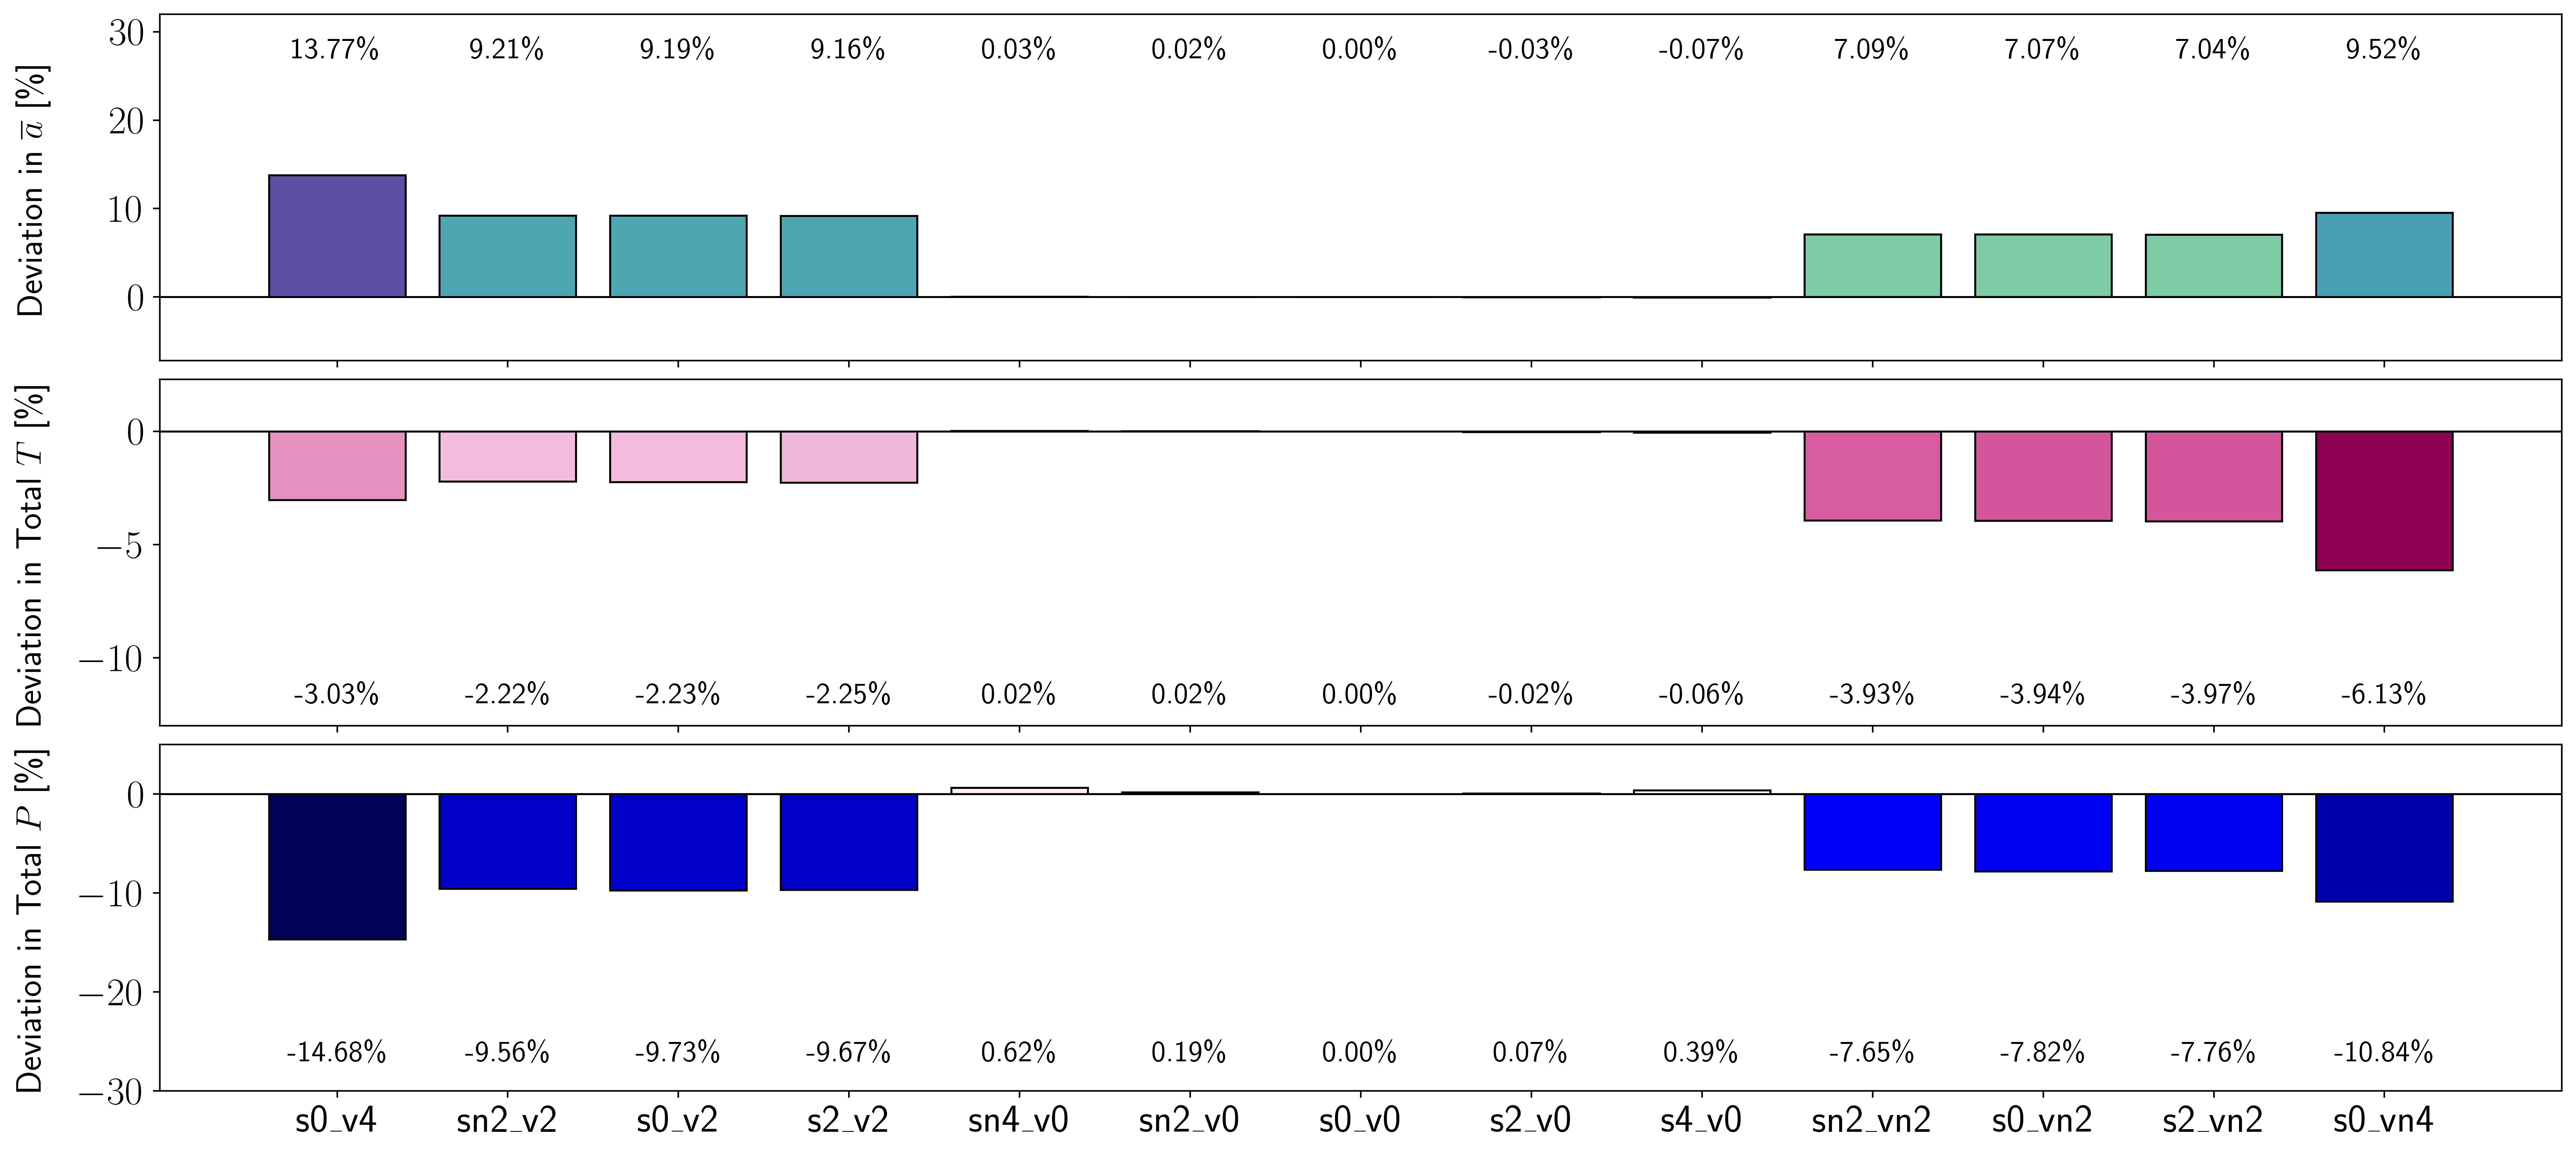

In [11]:
width = 0.75
alpha = 1.0

fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(18, 8), sharex=True, constrained_layout = True)
ax[0].axhline(0, color='black', linestyle='solid', linewidth=1)
ax[1].axhline(0, color='black', linestyle='solid', linewidth=1)
ax[2].axhline(0, color='black', linestyle='solid', linewidth=1)

ind = np.arange(len(casenames))

for count in range(len(casenames)):

    # induction
    ax[0].bar(ind[count], induction_dev[count], color=ind_cmap[count], edgecolor='black', alpha=alpha)
    ax[0].set_ylabel(r'Deviation in ${\overline{a}}$ [\%]', fontsize=fontsize*0.75, labelpad=30)
    ax[0].text(ind[count], 27, f'{induction_dev[count]:0.2f}\%', ha='center', fontsize=15)
    ax[0].set_ylim([-7.2,32])

    # thrust
    ax[1].bar(ind[count], thrust_dev[count], color=thr_cmap[count], edgecolor='black', alpha=alpha)
    ax[1].set_ylabel(r'Deviation in Total $T$ [\%]', fontsize=fontsize*0.75, labelpad=15)
    ax[1].text(ind[count], -12, f'{thrust_dev[count]:0.2f}\%', ha='center', fontsize=15)
    ax[1].set_ylim([-13,2.3])

    # power
    ax[2].bar(ind[count], power_dev[count], color=pow_cmap[count], edgecolor='black', alpha=alpha)
    ax[2].set_xticks(ind)
    ax[2].set_xticklabels(casenames)
    ax[2].set_ylabel(r'Deviation in Total $P$ [\%]', fontsize=fontsize*0.75, labelpad=15)
    ax[2].text(ind[count], -27, f'{power_dev[count]:0.2f}\%', ha='center', fontsize=15)
    ax[2].set_ylim([-30,5])

# plt.savefig("/scratch/09909/smata/wrf_les_sweep/runs/clockwise/gad_sweep/figs/rel_err_ind_thrust_torque_power.png", bbox_inches="tight", dpi=800)
plt.show()

In [11]:
n_levels = 100

power_int = np.max(np.abs([power - power[6]]))
p_min = np.max(np.abs(power[6] - power_int))/1000
p_max = np.max(np.abs(power[6] + power_int))/1000

thrust_int = np.max(np.abs([thrust - thrust[6]]))
t_min = np.max(np.abs(thrust[6] - thrust_int))/1000
t_max = np.max(np.abs(thrust[6] + thrust_int))/1000

induction_int = np.max(np.abs([induction - induction[6]]))
a_min = np.max(np.abs(induction[6] - induction_int))
a_max = np.max(np.abs(induction[6] + induction_int))

pow_levels = plt.colormaps['seismic'].resampled(n_levels)  # Extract 13 colors from 'viridis'
norm = mcolors.Normalize(vmin=p_min, vmax=p_max)  # Normalize power to [0, 1]
pow_cmap = [pow_levels(int(norm(p) * (n_levels - 1))) for p in power/1000]  # Map power to discrete colors

thr_levels = plt.colormaps['PiYG'].resampled(n_levels)  # Extract 13 colors from 'viridis'
norm = mcolors.Normalize(vmin=t_min, vmax=t_max)  # Normalize power to [0, 1]
thr_cmap = [thr_levels(int(norm(t) * (n_levels - 1))) for t in thrust/1000]  # Map power to discrete colors

ind_levels = plt.colormaps['BrBG'].resampled(n_levels)  # Extract 13 colors from 'viridis'
norm = mcolors.Normalize(vmin=a_min, vmax=a_max)  # Normalize power to [0, 1]
ind_cmap = [ind_levels(int(norm(a) * (n_levels - 1))) for a in induction]  # Map power to discrete colors

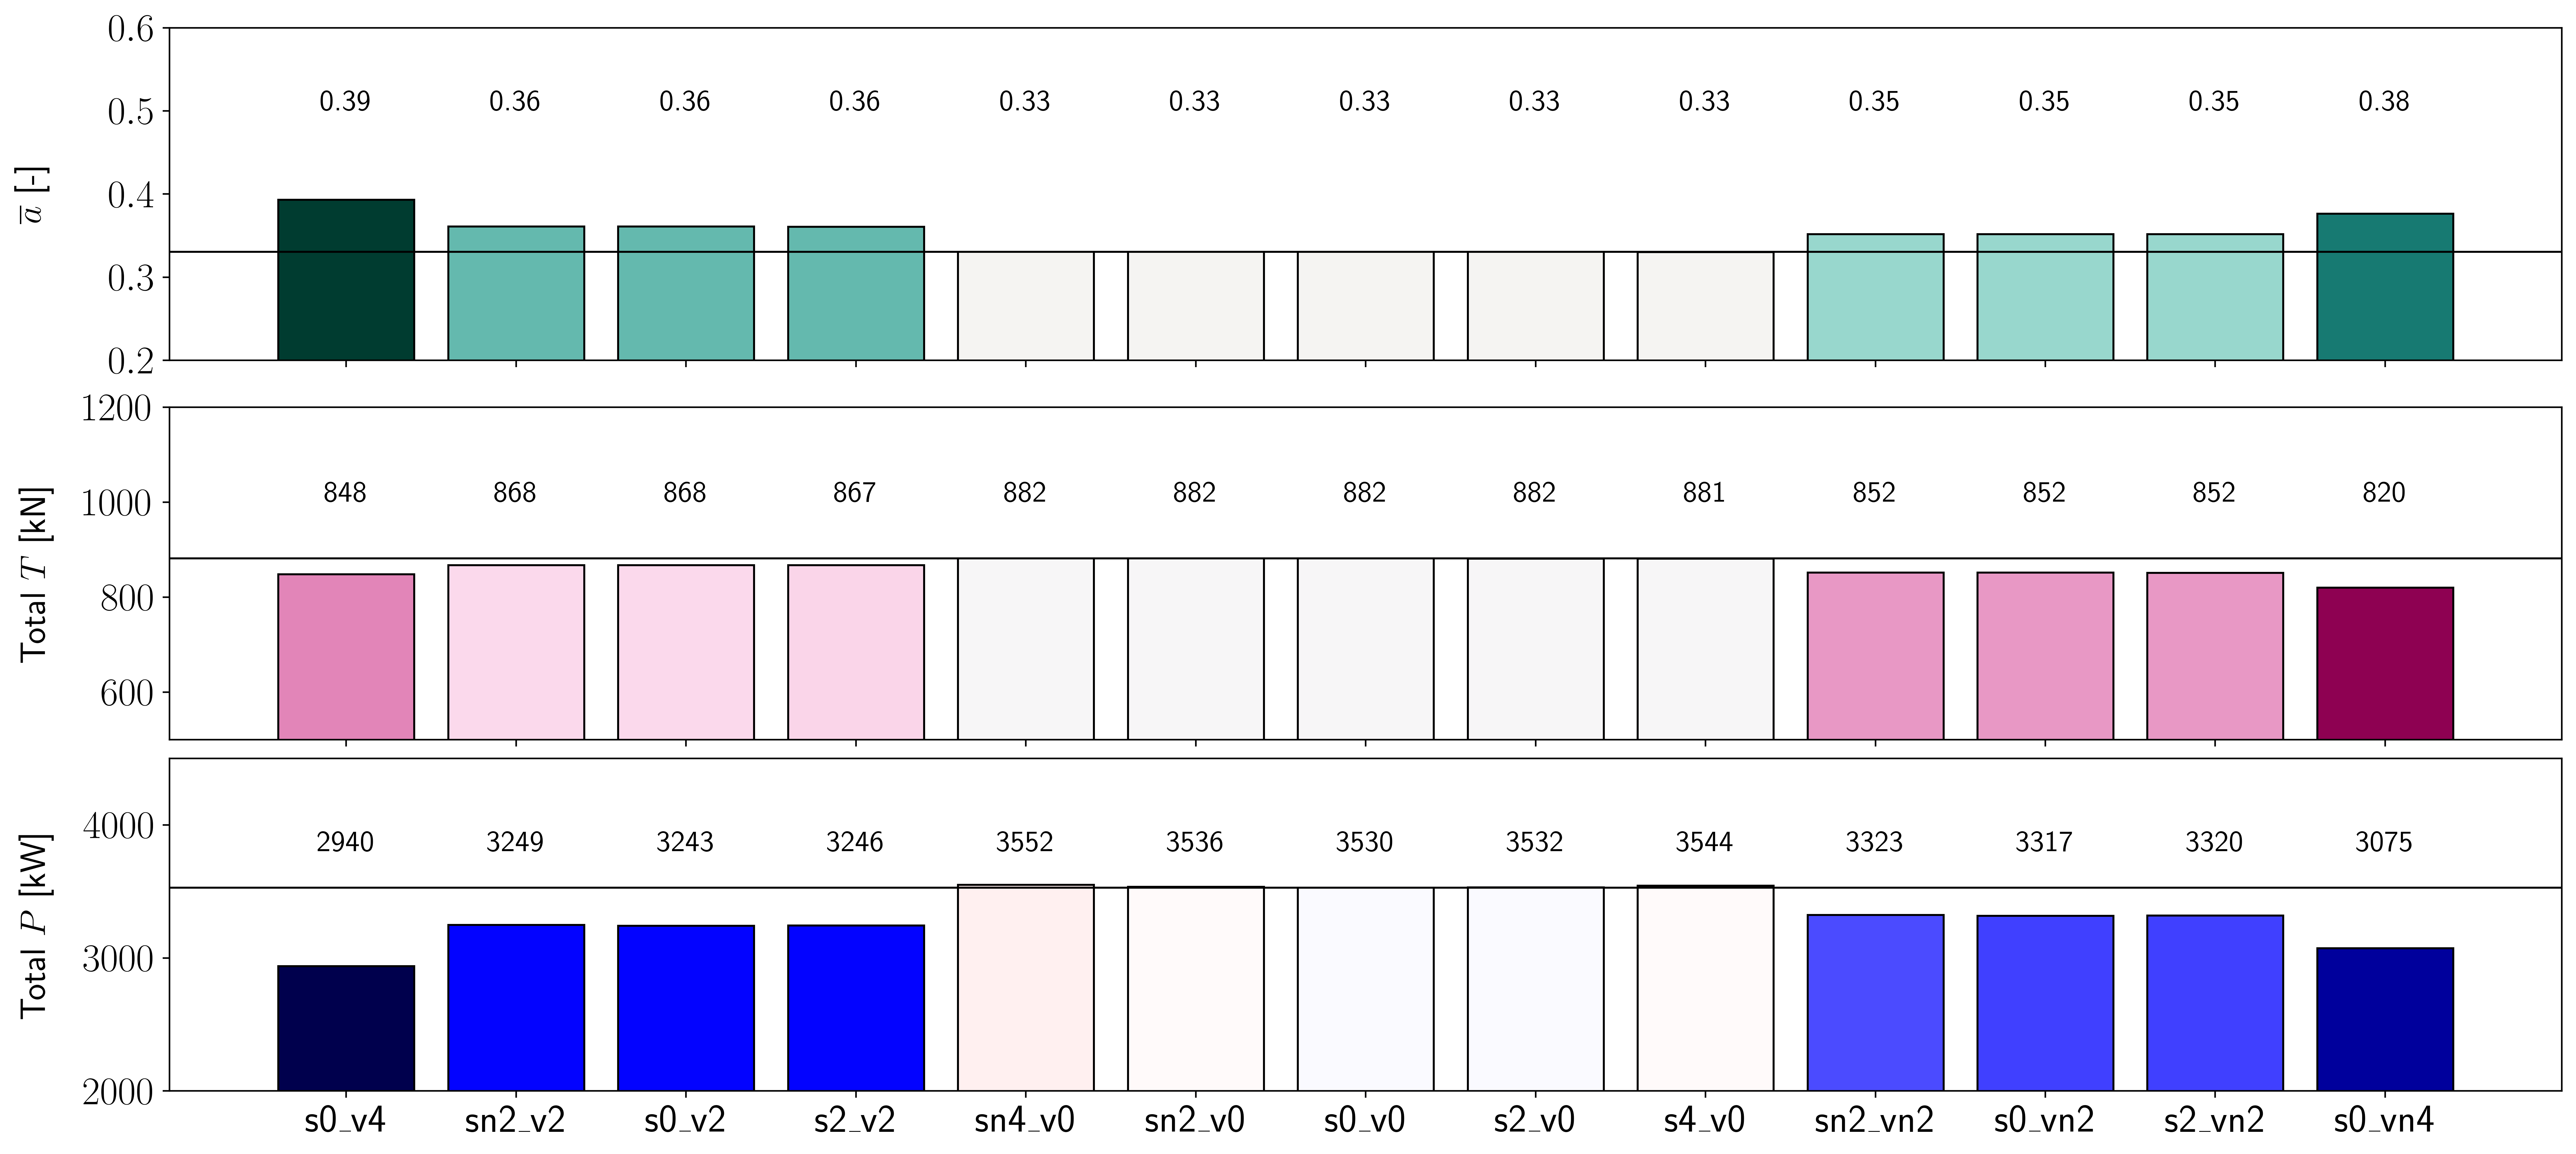

In [12]:
width = 0.75
alpha = 1.0

fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(18, 8), sharex=True, constrained_layout = True)
ax[0].axhline(induction[6], color='black', linestyle='solid', linewidth=1)
ax[1].axhline(thrust[6]/1000, color='black', linestyle='solid', linewidth=1)
ax[2].axhline(power[6]/1000, color='black', linestyle='solid', linewidth=1)

ind = np.arange(len(casenames))

for count in range(len(casenames)):

    # induction
    ax[0].bar(ind[count], induction[count], color=ind_cmap[count], edgecolor='black', alpha=alpha)
    ax[0].set_ylabel(r'${\overline{a}}$ [-]', fontsize=fontsize*0.75, labelpad=30)
    ax[0].text(ind[count], 0.5, f'{induction[count]:0.2f}', ha='center', fontsize=15)
    ax[0].set_ylim([0.2,0.6])

    # thrust
    ax[1].bar(ind[count], thrust[count]/1000, color=thr_cmap[count], edgecolor='black', alpha=alpha)
    ax[1].set_ylabel(r'Total $T$ [kN]', fontsize=fontsize*0.75, labelpad=15)
    ax[1].text(ind[count], 1000, f'{thrust[count]/1000:0.0f}', ha='center', fontsize=15)
    ax[1].set_ylim([500,1200])

    # power
    ax[2].bar(ind[count], power[count]/1000, color=pow_cmap[count], edgecolor='black', alpha=alpha)
    ax[2].set_xticks(ind)
    ax[2].set_xticklabels(casenames)
    ax[2].set_ylabel(r'Total $P$ [kW]', fontsize=fontsize*0.75, labelpad=15)
    ax[2].text(ind[count], 3800, f'{power[count]/1000:0.0f}', ha='center', fontsize=15)
    ax[2].set_ylim([2000,4500])

# plt.savefig("/scratch/09909/smata/wrf_les_sweep/runs/clockwise/gad_sweep/figs/rel_err_ind_thrust_torque_power.png", bbox_inches="tight", dpi=800)
plt.show()

In [13]:
cp

array([0.45310412, 0.50074523, 0.49982093, 0.50016807, 0.54736666,
       0.5449814 , 0.54397761, 0.54436565, 0.54615579, 0.51215169,
       0.51120569, 0.51156072, 0.47381353])

In [8]:
shear = [0,-2,0,2,-4,-2,0,2,4,-2,0,2,0]
veer= np.arange(-4,4.25,0.25)

cp        = np.zeros_like(casenames, dtype='float')
power     = np.zeros_like(casenames, dtype='float')
thrust    = np.zeros_like(casenames, dtype='float')
induction = np.zeros_like(casenames, dtype='float')

for count in range(len(casenames)):
    u_func = interp1d(data[casenames[count]][:,0],data[casenames[count]][:,1])
    v_func = interp1d(data[casenames[count]][:,0],data[casenames[count]][:,2])

    u = u_func(z)
    v = v_func(z)

    wdir = np.arctan2(v,u)

    U = (u**2 + v**2)**(1/2)

    bem = BEM(rotor=rotor, geometry=BEMGeometry(Nr=nElements, Ntheta=nSections), aerodynamic_model=KraghAerodynamics(), tiploss_model=NoTipLoss(), momentum_model=MadsenMomentum(), tangential_induction_model=NoTangentialInduction())

    sol = bem(pitch, tsr, yaw, v_inf=7.0, U = U/7, wdir = wdir)

    cp[count] = sol.Cp()
    power[count] = sol.power()
    thrust[count] = sol.thrust()
    induction[count] = sol.a()

In [9]:
cp

array([0.51178121, 0.51103054, 0.51027809, 0.50952105, 0.50876649,
       0.50800509, 0.50724657, 0.50648552, 0.50572525, 0.50496118,
       0.50419568, 0.50342994, 0.50266333, 0.50189386, 0.50112601,
       0.50035775, 0.49959052, 0.49882426, 0.49805899, 0.49729636,
       0.49653507, 0.49578009, 0.49503009, 0.49428505, 0.49354755,
       0.4928209 , 0.49210063, 0.49139243, 0.49069067, 0.49000626,
       0.48933056, 0.4886705 , 0.48802439])

In [11]:
induction

array([0.34929321, 0.34985115, 0.35041895, 0.35099614, 0.3515793 ,
       0.35217182, 0.35276802, 0.35337203, 0.35397825, 0.3545911 ,
       0.35520693, 0.35582447, 0.3564442 , 0.35706586, 0.3576875 ,
       0.35830835, 0.35892832, 0.35954653, 0.36016216, 0.3607752 ,
       0.36138511, 0.36199012, 0.3625902 , 0.36318604, 0.36377687,
       0.36435955, 0.36493833, 0.36550874, 0.36607454, 0.36663124,
       0.36718164, 0.3677232 , 0.36825579])